In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
Hwannier, cell_map = hwannier("wannier"), np.loadtxt("wannier.map.txt");
force_matrix, cellph_map = phonon_force_matrix("totalE");
Pwannier = pwannier("wannier");
Heph, celleph_map = hephwannier("wannier"), np.loadtxt("wannier.mapeph.txt");
lattice_vectors = loadlattice("wannier.out");

In [ ]:
# Plot of the wannierization scheme
plot_bands(Hwannier, cell_map, color="red", linewidth=4, whichbands=[4, 5])
plot_bands("totalE.bands.eigenvals", spin=1, color="blue", linewidth=1)
label_plots()
ylim(5, 0.71/eV)

In [5]:
subsampling_histogram = returnfermikpoint(Hwannier, cell_map, 13, Val(3), num_blocks=10, mesh=10, histogram_width=1)

(Real[0.201367024397741 0.9139984421815417 … 0.49589113445570865 0.7602544731971881; 0.4588152683122453 0.7560369864536518 … 0.742920640613207 0.4520412089601398; 0.4810485491105252 0.29792180103188026 … 0.624724348055153 0.7033085540907034], 0.12450000000000001)

In [6]:
# Cross check with Lorentzian or gaussian kernel
subsampling_gaussian = returnfermikpoint(Hwannier, cell_map, 13, Val(3), weight=Val(:gaussian), esmearing=0.08, num_blocks=50, mesh=10, histogram_width=1)

(Real[0.04225044152015078 0.027651683672571314 … 0.5100513860837983 0.8277789723692419; 0.544494178154268 0.774547854699619 … 0.9793410079800933 0.9381801619840406; 0.9262941334466308 0.30273153128270525 … 0.7870248289201558 0.49205857734858705], 0.07208)

In [36]:
#Calculating the density of states at the fermi surface
JJDFTX.dosatmu(Hwannier, cell_map, 13, Val(3), mesh=10, histogram_width=1, num_blocks=50)

0.12810000000000002

In [7]:
# Calculating the decay time through Shankar's method
tau_histogram =  τ(Hwannier, cell_map, Pwannier, force_matrix, cellph_map,
    Heph, celleph_map, collect(0.01:0.01:1), 13, Val(:histogram), Val(3); histogram_width=1, supplysampling=subsampling_histogram, num_blocks=50, supplydos=0.128,  mesh=10, fracroom=1)

DOS at Fermi Energy is: 0.128
Sampling from 1245kpoints
Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50


100-element Vector{Float64}:
 34.13215895400073
 34.10723644406714
 34.06742688170349
 34.01506645377187
 33.95297751439607
 33.88414476983898
 33.811429105782445
 33.73735713972736
 33.663999681382954
 33.59293164604711
 33.52525383701758
 33.46165339728664
 33.402482128543966
  ⋮
 32.618542404525925
 32.61698917481243
 32.615470225091556
 32.613984432903536
 32.612530724264396
 32.61110807107702
 32.60971548870636
 32.608352033706765
 32.60701680169054
 32.605708925327356
 32.60442757246548
 32.60317194436622

In [15]:
tau_gaussian =  τ(Hwannier, cell_map, Pwannier, force_matrix, cellph_map,
    Heph, celleph_map, collect(0.01:0.01:1), 13, Val(:gaussian), Val(3); histogram_width=1, supplysampling=subsampling_gaussian, num_blocks=50, esmearing=0.08, supplydos=0.128,  mesh=10, fracroom=1)

DOS at Fermi Energy is: 0.128
Sampling from 3604kpoints
Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50


100-element Vector{Float64}:
 32.28670699014057
 32.262804318082615
 32.22462451087932
 32.17440903507082
 32.11486562042174
 32.04885749235742
 31.979128789727003
 31.908102705789958
 31.837764976483534
 31.769625530883907
 31.70473948708951
 31.64376521959495
 31.58703953659834
  ⋮
 30.835734078716094
 30.83424597592064
 30.832790717603068
 30.831367228248116
 30.82997447879154
 30.828611484139103
 30.827277300842926
 30.825971024923714
 30.824691789828204
 30.82343876451207
 30.82221115163961
 30.821008185891824

In [63]:
tau_allen = zeros(100)
for i in 1:200
    tau_allen += np.loadtxt("boltzmann/boltzmann-1.txt")
end
tau_allen *= 1/200;

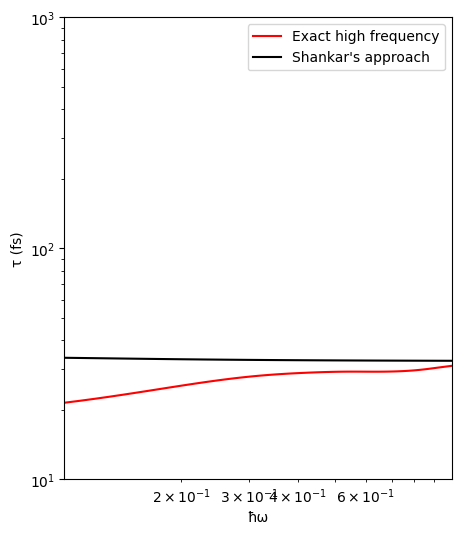

PyObject Text(24.000000000000007, 0.5, 'τ (fs)')

In [64]:
# comparison of exact high frequency result with Shankar's approach
figure(figsize=(5, 6))
loglog(collect(0.01:0.01:1)[10:end], smooth(tau_allen[10:end], win_len=50), color="red", label="Exact high frequency")
loglog(collect(0.01:0.01:1)[10:end], tau_histogram[10:end], color="black", label="Shankar's approach")
#loglog(collect(0.01:0.01:1)[10:end], tau_gaussian[10:end], color="black", label="Shankar's approach")

legend()
xlim(0.1, 1)
ylim(10, 1000)
gca().set_xticks([])
xlabel("ħω")
ylabel("τ (fs)")

In [65]:
np.savetxt("Ag_3D_tau.txt", tau_histogram)

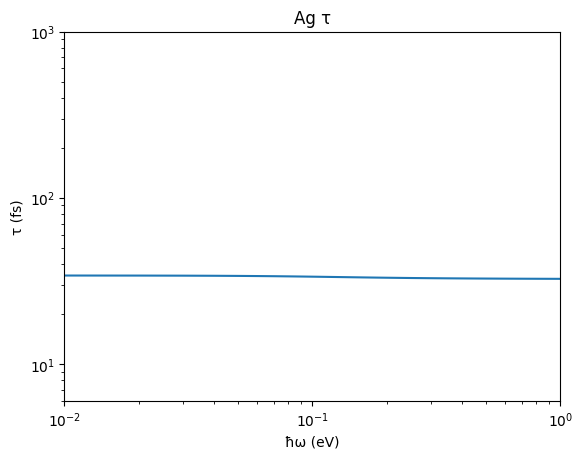

PyObject Text(24.000000000000007, 0.5, 'τ (fs)')

In [66]:
loglog(collect(0.01:0.01:1), np.loadtxt("Ag_3D_tau.txt"))
ylim(6, 1000)
xlim(0.01, 1)
title("Ag τ")
xlabel("ħω (eV)")
ylabel("τ (fs)")